# Results Comparison and Analysis

**Model:** Comparison of all four coupling architectures (PA, PD, TA, TD)

## Overview

This notebook loads pre-computed results from saved .npz files and generates comprehensive comparison figures across all four Wilson-Cowan coupling architectures (Second-order Additive, Second-order Diffusive, Third-Order Additive, and Third-Order Diffusive). It visualizes how different coupling mechanisms lead to the emergence of higher-order statistical structure and evaluates the main findings of the paper 'Higher-order statistical structure emerges from nonlinear dynamics without explicit third-order coupling'.

## Key Sections

- **Load saved results:** Import parameter sweep data from results/ directory
- **Generate comparison figures:** Create visualizations comparing metrics across all four coupling architectures

---

### Load Saved Results

Import parameter sweep results from saved .npz files in the results/ directory for all four coupling architectures.


(-0.7067348788080405, 1.7944147776399841)

Saved → ../results/fig1_PK_additive.pdf
Saved → ../results/fig2_PK_diffusive.pdf
Saved → ../results/fig3_aK_additive.pdf
Saved → ../results/fig4_aK_diffusive.pdf


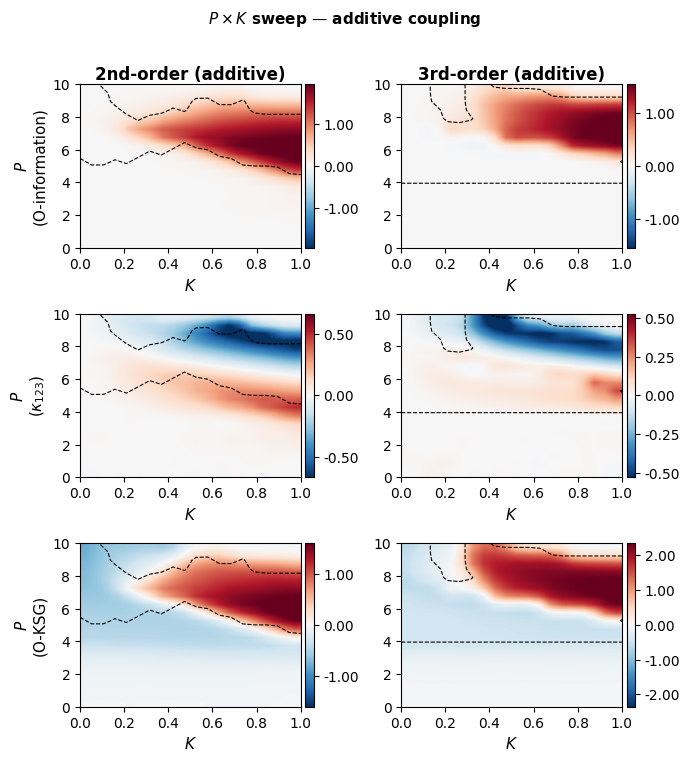

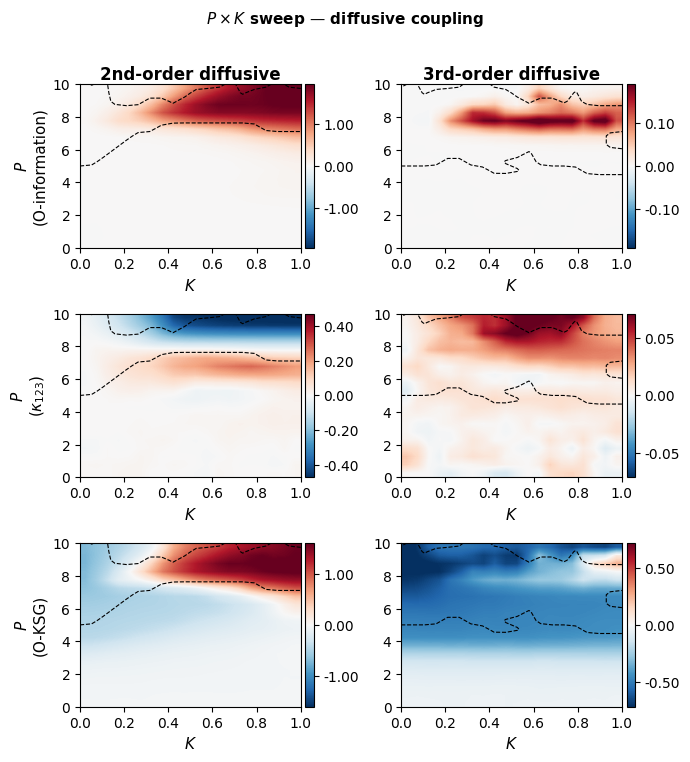

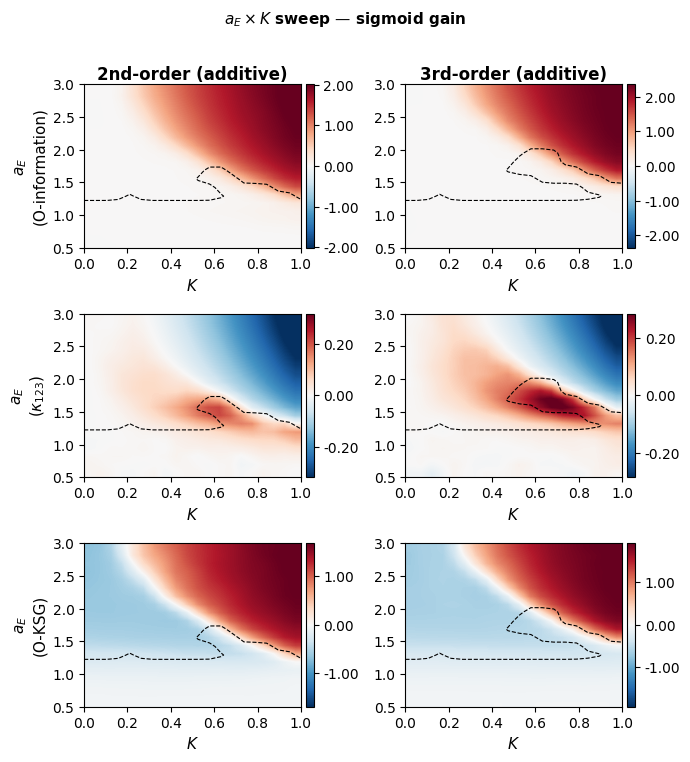

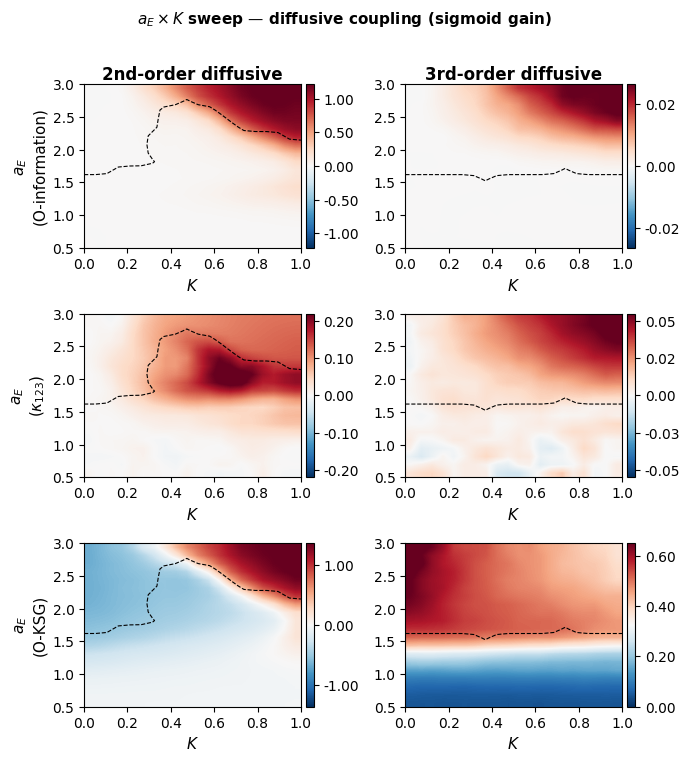

Done — 4 three-node figures generated.


In [52]:
"""
plot_smooth_metrics.py
-----------------------
Smoothing + imputation of Wilson-Cowan metric matrices and
generation of 4 publication-quality figures for a 2-column RevTeX paper.

Grid per figure:  3 rows × 2 cols
  Rows:  O-information (TC−DTC),  k₁₂₃ (cumulant),  O-information KSG
  Cols:  2nd-order  vs  3rd-order

Figures:
  fig1 — P × K, additive coupling
  fig2 — P × K, diffusive coupling
  fig3 — a_E × K, additive coupling
  fig4 — a_E × K, diffusive coupling
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter, generic_filter
from scipy.stats import zscore

import matplotlib as mpl
mpl.rcParams.update({
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
})


# ── 0.  Load data ────────────────────────────────────────────────────────────

pairwise           = np.load("../results/raw_metrics_Pairwise_noise.npz")
pairwise_diffusive = np.load("../results/raw_metrics_Pairwise_diffusive_noise.npz")
coupling           = np.load("../results/raw_metrics_Coupling_noise.npz")
coupling_diffusive = np.load("../results/raw_metrics_Coupling_diffusive_noise.npz")
pairwise_a         = np.load("../results/raw_metrics_Pairwise_noise_a.npz")
coupling_a         = np.load("../results/raw_metrics_Coupling_noise_a.npz")
pairwise_diffusive_a = np.load("../results/raw_metrics_Pairwise_diffusive_noise_a.npz")
coupling_diffusive_a = np.load("../results/raw_metrics_Coupling_diffusive_noise_a.npz")


# ── 1.  Smoothing / imputation helpers ───────────────────────────────────────

def detect_outliers(mat: np.ndarray, z_thresh: float = 2.5) -> np.ndarray:
    z = np.abs(zscore(mat.ravel()))
    return z.reshape(mat.shape) > z_thresh

def neighbour_median(values: np.ndarray) -> float:
    centre_idx = len(values) // 2
    neighbours = np.concatenate([values[:centre_idx], values[centre_idx + 1:]])
    valid = neighbours[~np.isnan(neighbours)]
    return np.median(valid) if len(valid) > 0 else np.nan

def impute_outliers(mat, mask, max_iter=10):
    work = mat.astype(float).copy()
    work[mask] = np.nan
    footprint = np.ones((3, 3), dtype=bool)
    footprint[1, 1] = False
    for _ in range(max_iter):
        nan_mask = np.isnan(work)
        if not nan_mask.any():
            break
        filled = generic_filter(work, neighbour_median,
                                footprint=footprint, mode='nearest')
        work[nan_mask] = filled[nan_mask]
    if np.isnan(work).any():
        work[np.isnan(work)] = np.nanmedian(work)
    return work

def smooth_matrix(mat, z_thresh=2.5, sigma=0.8, max_iter=10):
    mask = detect_outliers(mat, z_thresh=z_thresh)
    imputed = impute_outliers(mat, mask, max_iter=max_iter)
    return gaussian_filter(imputed, sigma=sigma)


# ── 2.  Metric extraction ────────────────────────────────────────────────────

def get_metrics(data, a_sweep=False):
    """Return (tc_dtc, cumulant, Oinfo_ksg, oscillation, P_vals, K_vals, y_label)."""
    TC  = data["TC"]
    DTC = data["DTC"]
    tc_dtc    = TC - DTC
    cumulant  = data["cumulant"]
    Oinfo_ksg = data["Oinfo_ksg"]
    oscillation = data["oscillation_map"]

    if (np.max(Oinfo_ksg)<0 and np.min(Oinfo_ksg))<0:
        Oinfo_ksg = np.abs(Oinfo_ksg)

    K_values = np.linspace(0.0, 1.0, 20)
    if a_sweep:
        P_values = np.linspace(0.5, 3.0, 20)
        y_label  = r"$a_E$"
    else:
        P_values = np.linspace(0.0, 10.0, 20)
        y_label  = r"$P$"

    return tc_dtc, cumulant, Oinfo_ksg, oscillation, P_values, K_values, y_label


# ── 3.  Single-panel plot function ───────────────────────────────────────────

def plot_panel(ax, matrix, oscillation, x_vals, y_vals,
               title="", xlabel="K", ylabel="",
               cmap="RdBu_r", show_osc=True,
               z_thresh=2.5, sigma=0.8):
    smoothed = smooth_matrix(matrix, z_thresh=z_thresh, sigma=sigma)

    vmax = np.nanpercentile(np.abs(smoothed), 98)
    vmin = -vmax if (smoothed.min() < 0 < smoothed.max()) else 0

    im = ax.imshow(
        smoothed, origin='lower', aspect='auto',
        extent=[x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]],
        cmap=cmap, vmin=vmin, vmax=vmax, interpolation='bilinear',
    )

    if show_osc and oscillation is not None:
        osc_smooth = gaussian_filter(oscillation.astype(float), sigma=0.6)
        ax.contour(
            np.linspace(x_vals[0], x_vals[-1], oscillation.shape[1]),
            np.linspace(y_vals[0], y_vals[-1], oscillation.shape[0]),
            osc_smooth, levels=[0.5],
            colors='k', linewidths=0.8, linestyles='--',
        )

    cb = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cb.ax.tick_params(labelsize=10)
    cb.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    ax.set_title(title, fontsize=12, fontweight='bold', pad=3)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(labelsize=10)
    return im


# ── 4.  Figure factory — 3×2 grid ────────────────────────────────────────────

FIG_W  = 7.0
FIG_H  = 7.5      # taller to accommodate 3 rows
FONTSIZE_SUPTITLE = 11

ROW_LABELS = [r"O-information", r"$\kappa_{123}$", r"O-KSG"]


def make_figure(left_data, right_data,
                left_title, right_title,
                a_sweep_left=False, a_sweep_right=False,
                fig_title="", savepath=None,
                z_thresh=2.5, sigma=0.8):
    """
    3×2 figure:
        col 0 = 2nd-order    |  col 1 = 3rd-order
        row 0 = TC − DTC     |
        row 1 = cumulant     |
        row 2 = Oinfo_ksg    |
    """
    tc_L, cum_L, ksg_L, osc_L, P_L, K_L, ylab_L = get_metrics(left_data,  a_sweep=a_sweep_left)
    tc_R, cum_R, ksg_R, osc_R, P_R, K_R, ylab_R = get_metrics(right_data, a_sweep=a_sweep_right)

    fig, axes = plt.subplots(3, 2, figsize=(FIG_W, FIG_H))
    fig.suptitle(fig_title, fontsize=FONTSIZE_SUPTITLE, fontweight='bold', y=1.01)

    data_pairs = [
        (tc_L,  osc_L, P_L, K_L, ylab_L,  tc_R,  osc_R, P_R, K_R, ylab_R),
        (cum_L, osc_L, P_L, K_L, ylab_L,  cum_R, osc_R, P_R, K_R, ylab_R),
        (ksg_L, osc_L, P_L, K_L, ylab_L,  ksg_R, osc_R, P_R, K_R, ylab_R),
    ]

    for row, (dL, oL, PL, KL, ylL,
              dR, oR, PR, KR, ylR) in enumerate(data_pairs):

        col_title_L = left_title  if row == 0 else ""
        col_title_R = right_title if row == 0 else ""

        plot_panel(axes[row, 0], dL, oL,
                   x_vals=KL, y_vals=PL,
                   title=col_title_L,
                   xlabel=r"$K$", ylabel=ylL,
                   z_thresh=z_thresh, sigma=sigma)
        axes[row, 0].set_ylabel(f"{ylL}\n({ROW_LABELS[row]})", fontsize=11)

        plot_panel(axes[row, 1], dR, oR,
                   x_vals=KR, y_vals=PR,
                   title=col_title_R,
                   xlabel=r"$K$", ylabel=ylR,
                   z_thresh=z_thresh, sigma=sigma)
        axes[row, 1].set_ylabel("")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Saved → {savepath}")
    return fig


# ── 5.  Generate the four 3-node figures ──────────────────────────────────────

# Fig 1: P × K — additive
make_figure(
    left_data=pairwise, right_data=coupling,
    left_title="2nd-order (additive)", right_title="3rd-order (additive)",
    fig_title=r"$P \times K$ sweep — additive coupling",
    savepath="../results/fig1_PK_additive.pdf",
    z_thresh=2.8, sigma=0.7
)

# Fig 2: P × K — diffusive
make_figure(
    left_data=pairwise_diffusive, right_data=coupling_diffusive,
    left_title="2nd-order diffusive", right_title="3rd-order diffusive",
    fig_title=r"$P \times K$ sweep — diffusive coupling",
    savepath="../results/fig2_PK_diffusive.pdf",
    z_thresh=2.8, sigma=0.7
)

# Fig 3: a_E × K — additive
make_figure(
    left_data=pairwise_a, right_data=coupling_a,
    left_title="2nd-order (additive)", right_title="3rd-order (additive)",
    a_sweep_left=True, a_sweep_right=True,
    fig_title=r"$a_E \times K$ sweep — sigmoid gain",
    savepath="../results/fig3_aK_additive.pdf",
    z_thresh=2.8, sigma=0.7
)

# Fig 4: a_E × K — diffusive
make_figure(
    left_data=pairwise_diffusive_a, right_data=coupling_diffusive_a,
    left_title="2nd-order diffusive", right_title="3rd-order diffusive",
    a_sweep_left=True, a_sweep_right=True,
    fig_title=r"$a_E \times K$ sweep — diffusive coupling (sigmoid gain)",
    savepath="../results/fig4_aK_diffusive.pdf",
    z_thresh=2.8, sigma=0.7
)

plt.show()
print("Done — 4 three-node figures generated.")


In [2]:
pairwise_a

NpzFile '../results/raw_metrics_Pairwise_noise_a.npz' with keys: oscillation_map, TC, DTC, cumulant, powercorr...

### 10-Node Network Models

P × K contour plots for the **Ring Small-World** and **Random (Erdős–Rényi)** 10-node networks.
Same 3×2 layout: O-information, κ₁₂₃, O-KSG.  Columns: 2nd-order vs 3rd-order (additive coupling).

Saved → ../results/fig_10n_ring_PK.pdf
Saved → ../results/fig_10n_random_PK.pdf


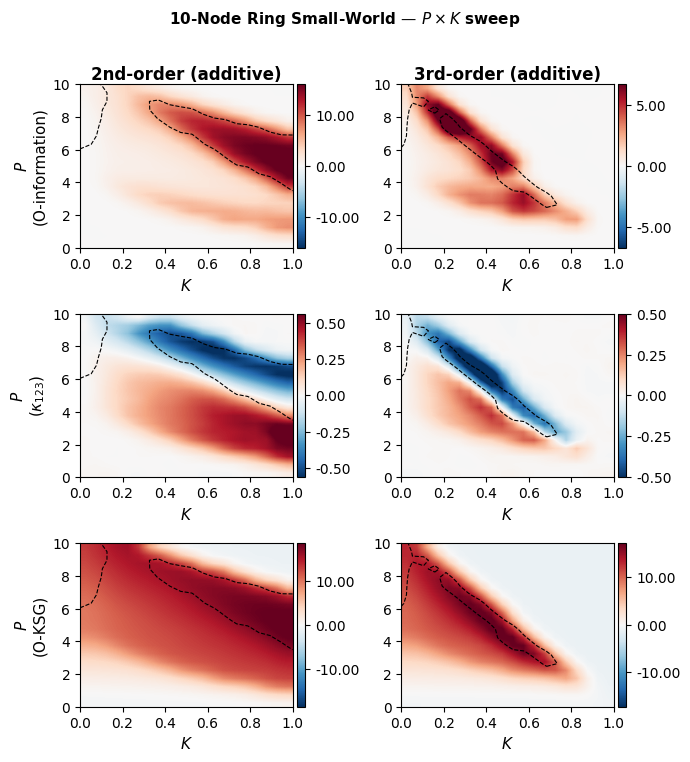

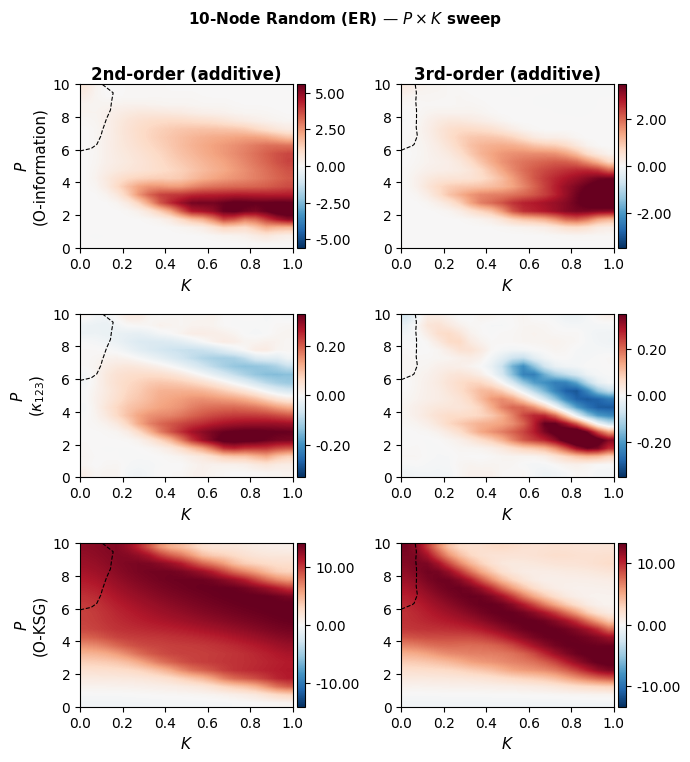

Done — 2 ten-node figures generated.


In [51]:
"""
plot_10node_metrics.py
-----------------------
10-node network results — Ring Small-World & Random topologies.
Uses the identical smoothing pipeline and plot_panel from the 3-node cell.

Generates:
  fig_10n_ring_PK.pdf   — Ring Small-World, P × K, additive coupling
  fig_10n_random_PK.pdf — Random, P × K, additive coupling
"""

# ── Load 10-node data ────────────────────────────────────────────────────────

ring_2nd = np.load("../results/raw_metrics_10n_ring_sw_pairwise_noise.npz")
ring_3rd = np.load("../results/raw_metrics_10n_ring_sw_coupling_noise.npz")
rand_2nd = np.load("../results/raw_metrics_10n_random_pairwise_noise.npz")
rand_3rd = np.load("../results/raw_metrics_10n_random_coupling_noise.npz")


def get_metrics_10n(data):
    """Extract metrics for 10-node data (P × K only, additive)."""
    TC  = data["TC"]
    DTC = data["DTC"]
    tc_dtc    = TC - DTC
    cumulant  = data["cumulant"]
    Oinfo_ksg = data["Oinfo_ksg"]
    # 10-node uses osc_fraction (continuous); fall back to oscillation_map
    oscillation = data.get("osc_fraction", data["oscillation_map"]).astype(float)

    P_values = data["P"]
    K_values = data["K3"]
    return tc_dtc, cumulant, Oinfo_ksg, oscillation, P_values, K_values


def make_figure_10n(left_data, right_data,
                    left_title, right_title,
                    fig_title="", savepath=None,
                    z_thresh=2.5, sigma=0.8):
    """
    3×2 figure for 10-node models (identical layout to 3-node).
    """
    tc_L, cum_L, ksg_L, osc_L, P_L, K_L = get_metrics_10n(left_data)
    tc_R, cum_R, ksg_R, osc_R, P_R, K_R = get_metrics_10n(right_data)

    fig, axes = plt.subplots(3, 2, figsize=(FIG_W, FIG_H))
    fig.suptitle(fig_title, fontsize=FONTSIZE_SUPTITLE, fontweight='bold', y=1.01)

    data_pairs = [
        (tc_L,  osc_L, P_L, K_L,  tc_R,  osc_R, P_R, K_R),
        (cum_L, osc_L, P_L, K_L,  cum_R, osc_R, P_R, K_R),
        (ksg_L, osc_L, P_L, K_L,  ksg_R, osc_R, P_R, K_R),
    ]

    for row, (dL, oL, PL, KL, dR, oR, PR, KR) in enumerate(data_pairs):
        col_title_L = left_title  if row == 0 else ""
        col_title_R = right_title if row == 0 else ""

        plot_panel(axes[row, 0], dL, oL,
                   x_vals=KL, y_vals=PL,
                   title=col_title_L,
                   xlabel=r"$K$", ylabel=r"$P$",
                   z_thresh=z_thresh, sigma=sigma)
        axes[row, 0].set_ylabel(f"$P$\n({ROW_LABELS[row]})", fontsize=11)

        plot_panel(axes[row, 1], dR, oR,
                   x_vals=KR, y_vals=PR,
                   title=col_title_R,
                   xlabel=r"$K$", ylabel=r"$P$",
                   z_thresh=z_thresh, sigma=sigma)
        axes[row, 1].set_ylabel("")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Saved → {savepath}")
    return fig


# ── Ring Small-World ──────────────────────────────────────────────────────────
make_figure_10n(
    left_data=ring_2nd, right_data=ring_3rd,
    left_title="2nd-order (additive)", right_title="3rd-order (additive)",
    fig_title=r"10-Node Ring Small-World — $P \times K$ sweep",
    savepath="../results/fig_10n_ring_PK.pdf",
    z_thresh=2.8, sigma=0.8
)

# ── Random ────────────────────────────────────────────────────────────────────
make_figure_10n(
    left_data=rand_2nd, right_data=rand_3rd,
    left_title="2nd-order (additive)", right_title="3rd-order (additive)",
    fig_title=r"10-Node Random (ER) — $P \times K$ sweep",
    savepath="../results/fig_10n_random_PK.pdf",
    z_thresh=2.8, sigma=0.8
)

plt.show()
print("Done — 2 ten-node figures generated.")


### Bifurcation Diagrams (Numerical Continuation)

Hopf bifurcation boundaries computed via eigenvalue analysis of the network Jacobian.
For each value of the swept parameter, we find the equilibrium (via `fsolve`) and compute the
eigenvalues of the analytically derived Jacobian. The Hopf boundary is where the maximum
real part of the eigenvalues crosses zero.

Stable Rank  (M): 1.50
Nuclear Rank (M): 2.00
Effective Rank (95% energy, M): 3
Computing Hopf boundaries (this may take a few minutes)...
  2nd-order additive — P×K sweep...


/var/folders/f5/3603lrxn363_ddpmt3c65sfm0000gn/T/ipykernel_39883/2673673937.py:201: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  eq = fsolve(lambda s: rhs_fn(s, P_vec, K_val, params, connectivity),
/var/folders/f5/3603lrxn363_ddpmt3c65sfm0000gn/T/ipykernel_39883/2673673937.py:201: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  eq = fsolve(lambda s: rhs_fn(s, P_vec, K_val, params, connectivity),


  2nd-order diffusive — P×K sweep...
  3rd-order additive — P×K sweep...
  3rd-order diffusive — P×K sweep...
  2nd-order additive — a_E×K sweep...
  2nd-order diffusive — a_E×K sweep...
  3rd-order additive — a_E×K sweep...
  3rd-order diffusive — a_E×K sweep...
Done computing.
Saved → fig5_bifurcation_PK.pdf


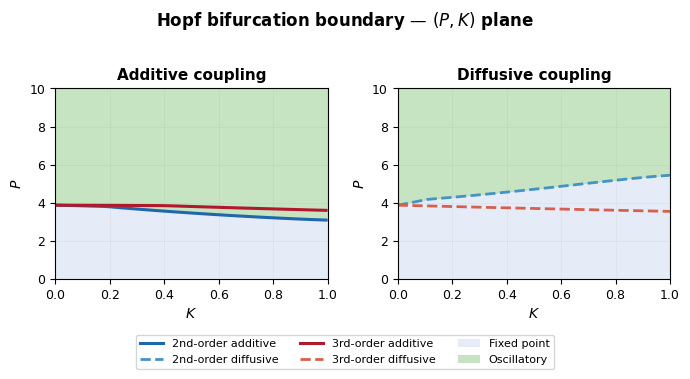

Saved → fig6_bifurcation_aK.pdf


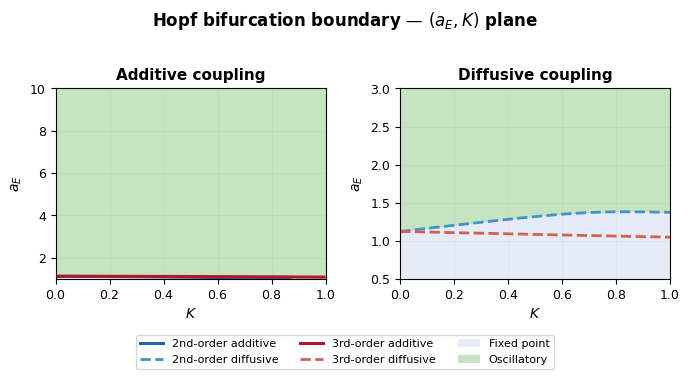


Done — bifurcation diagrams with numerical continuation.
Saved → fig7_bifurcation_10n_PK.pdf


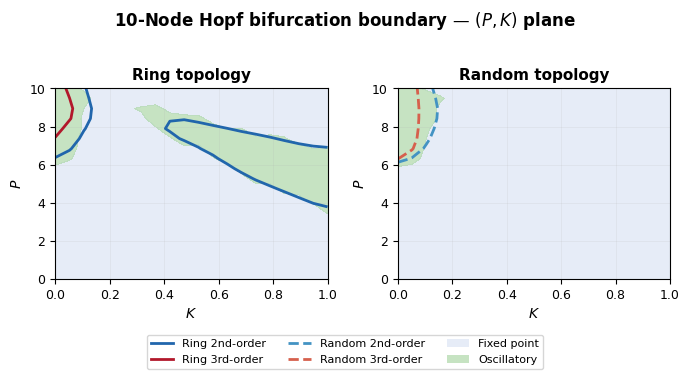


Done — all bifurcation diagrams generated.


In [4]:
"""
bifurcation_continuation.py
───────────────────────────
Numerical continuation of Hopf bifurcation boundaries for the four
Wilson-Cowan coupling architectures.

Method:
  1. For a dense grid of (param, K), find the equilibrium via fsolve.
  2. Compute the Jacobian analytically at the equilibrium.
  3. Compute eigenvalues; record max(Re(λ)).
  4. The Hopf boundary is the zero-crossing of max(Re(λ)).

Produces two publication-quality figures:
  - Fig 5: Hopf boundaries in the (P, K) plane
  - Fig 6: Hopf boundaries in the (a_E, K) plane
"""

import sys, os
sys.path.append('../')
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

from Scripts.parameters import param_nodes, M, T_ho, N_nodes

mpl.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})

# ── Sigmoid and its derivative ───────────────────────────────────────────────

def sigmoid(x, a):
    return 1.0 / (1.0 + np.exp(-a * x))

def sigmoid_prime(x, a):
    s = sigmoid(x, a)
    return a * s * (1.0 - s)

# ── RHS functions for each model ─────────────────────────────────────────────

def rhs_pairwise_additive(state, P_vec, K, params, M_mat):
    N = len(params)
    E, I = state[:N], state[N:]
    coupling = K * (M_mat @ E)
    dE = np.zeros(N); dI = np.zeros(N)
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        dE[i] = (-E[i] + sigmoid(p['cEE']*E[i] - p['cEI']*I[i] + P_i + coupling[i], p['aE'])) / p['tauE']
        dI[i] = (-I[i] + sigmoid(p['cIE']*E[i] - p['cII']*I[i] + p['Q'], p['aI'])) / p['tauI']
    return np.concatenate([dE, dI])

def rhs_pairwise_diffusive(state, P_vec, K, params, M_mat):
    N = len(params)
    E, I = state[:N], state[N:]
    degree = M_mat.sum(axis=1)
    coupling = K * (M_mat @ E - degree * E)
    dE = np.zeros(N); dI = np.zeros(N)
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        dE[i] = (-E[i] + sigmoid(p['cEE']*E[i] - p['cEI']*I[i] + P_i + coupling[i], p['aE'])) / p['tauE']
        dI[i] = (-I[i] + sigmoid(p['cIE']*E[i] - p['cII']*I[i] + p['Q'], p['aI'])) / p['tauI']
    return np.concatenate([dE, dI])

def rhs_thirdorder_additive(state, P_vec, K3, params, T_tensor):
    N = len(params)
    E, I = state[:N], state[N:]
    dE = np.zeros(N); dI = np.zeros(N)
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        ho_input = sum(T_tensor[i,j,k]*E[j]*E[k] for j in range(N) for k in range(N))
        dE[i] = (-E[i] + sigmoid(p['cEE']*E[i] - p['cEI']*I[i] + P_i + K3*ho_input, p['aE'])) / p['tauE']
        dI[i] = (-I[i] + sigmoid(p['cIE']*E[i] - p['cII']*I[i] + p['Q'], p['aI'])) / p['tauI']
    return np.concatenate([dE, dI])

def rhs_thirdorder_diffusive(state, P_vec, K3, params, T_tensor):
    N = len(params)
    E, I = state[:N], state[N:]
    dE = np.zeros(N); dI = np.zeros(N)
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        diff = E - E[i]
        ho_input = diff @ T_tensor[i] @ diff
        dE[i] = (-E[i] + sigmoid(p['cEE']*E[i] - p['cEI']*I[i] + P_i + K3*ho_input, p['aE'])) / p['tauE']
        dI[i] = (-I[i] + sigmoid(p['cIE']*E[i] - p['cII']*I[i] + p['Q'], p['aI'])) / p['tauI']
    return np.concatenate([dE, dI])

# ── Analytical Jacobian ──────────────────────────────────────────────────────

def jacobian_pairwise_additive(state, P_vec, K, params, M_mat):
    N = len(params)
    E, I = state[:N], state[N:]
    coupling = K * (M_mat @ E)
    J = np.zeros((2*N, 2*N))
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        hE = p['cEE']*E[i] - p['cEI']*I[i] + P_i + coupling[i]
        hI = p['cIE']*E[i] - p['cII']*I[i] + p['Q']
        sE = sigmoid_prime(hE, p['aE'])
        sI = sigmoid_prime(hI, p['aI'])
        # dE_i/dE_j
        J[i, i] = (-1 + sE * p['cEE']) / p['tauE']
        for j in range(N):
            if j != i:
                J[i, j] = sE * K * M_mat[i, j] / p['tauE']
        # dE_i/dI_i
        J[i, N+i] = -sE * p['cEI'] / p['tauE']
        # dI_i/dE_i
        J[N+i, i] = sI * p['cIE'] / p['tauI']
        # dI_i/dI_i
        J[N+i, N+i] = (-1 - sI * p['cII']) / p['tauI']
    return J

def jacobian_pairwise_diffusive(state, P_vec, K, params, M_mat):
    N = len(params)
    E, I = state[:N], state[N:]
    degree = M_mat.sum(axis=1)
    coupling = K * (M_mat @ E - degree * E)
    J = np.zeros((2*N, 2*N))
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        hE = p['cEE']*E[i] - p['cEI']*I[i] + P_i + coupling[i]
        hI = p['cIE']*E[i] - p['cII']*I[i] + p['Q']
        sE = sigmoid_prime(hE, p['aE'])
        sI = sigmoid_prime(hI, p['aI'])
        J[i, i] = (-1 + sE * (p['cEE'] - K * degree[i])) / p['tauE']
        for j in range(N):
            if j != i:
                J[i, j] = sE * K * M_mat[i, j] / p['tauE']
        J[i, N+i] = -sE * p['cEI'] / p['tauE']
        J[N+i, i] = sI * p['cIE'] / p['tauI']
        J[N+i, N+i] = (-1 - sI * p['cII']) / p['tauI']
    return J

def jacobian_thirdorder_additive(state, P_vec, K3, params, T_tensor):
    N = len(params)
    E, I = state[:N], state[N:]
    J = np.zeros((2*N, 2*N))
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        ho_input = sum(T_tensor[i,j,k]*E[j]*E[k] for j in range(N) for k in range(N))
        hE = p['cEE']*E[i] - p['cEI']*I[i] + P_i + K3*ho_input
        hI = p['cIE']*E[i] - p['cII']*I[i] + p['Q']
        sE = sigmoid_prime(hE, p['aE'])
        sI = sigmoid_prime(hI, p['aI'])
        # d(ho_input)/dE_m = sum_k T[i,m,k]*E[k] + sum_j T[i,j,m]*E[j]
        for m in range(N):
            dho_dEm = sum(T_tensor[i,m,k]*E[k] for k in range(N)) + sum(T_tensor[i,j,m]*E[j] for j in range(N))
            if m == i:
                J[i, m] = (-1 + sE * (p['cEE'] + K3 * dho_dEm)) / p['tauE']
            else:
                J[i, m] = sE * K3 * dho_dEm / p['tauE']
        J[i, N+i] = -sE * p['cEI'] / p['tauE']
        J[N+i, i] = sI * p['cIE'] / p['tauI']
        J[N+i, N+i] = (-1 - sI * p['cII']) / p['tauI']
    return J

def jacobian_thirdorder_diffusive(state, P_vec, K3, params, T_tensor):
    N = len(params)
    E, I = state[:N], state[N:]
    J = np.zeros((2*N, 2*N))
    for i in range(N):
        p = params[i]; P_i = P_vec[i]
        diff = E - E[i]
        ho_input = diff @ T_tensor[i] @ diff
        hE = p['cEE']*E[i] - p['cEI']*I[i] + P_i + K3*ho_input
        hI = p['cIE']*E[i] - p['cII']*I[i] + p['Q']
        sE = sigmoid_prime(hE, p['aE'])
        sI = sigmoid_prime(hI, p['aI'])
        Ti = T_tensor[i]
        for m in range(N):
            # d(ho_input)/dE_m where ho = sum_{j,k} T[i,j,k]*(E_j-E_i)*(E_k-E_i)
            if m == i:
                dho = -2.0 * (Ti @ diff).sum()  # derivative w.r.t. E_i
            else:
                dho = 2.0 * (Ti[m, :] @ diff + Ti[:, m] @ diff) / 2.0
                # More precisely: d/dE_m = sum_k T[i,m,k]*(E_k-E_i) + sum_j T[i,j,m]*(E_j-E_i)
                dho = sum(Ti[m,k]*diff[k] for k in range(N)) + sum(Ti[j,m]*diff[j] for j in range(N))
            if m == i:
                J[i, m] = (-1 + sE * (p['cEE'] + K3 * dho)) / p['tauE']
            else:
                J[i, m] = sE * K3 * dho / p['tauE']
        J[i, N+i] = -sE * p['cEI'] / p['tauE']
        J[N+i, i] = sI * p['cIE'] / p['tauI']
        J[N+i, N+i] = (-1 - sI * p['cII']) / p['tauI']
    return J

# ── Equilibrium finder + stability ───────────────────────────────────────────

def find_equilibrium_and_max_eig(rhs_fn, jac_fn, P_vec, K_val, params,
                                  connectivity, x0=None):
    """
    Find equilibrium via fsolve, compute Jacobian eigenvalues, return
    max real part and the equilibrium state.
    """
    if x0 is None:
        x0 = 0.3 * np.ones(2 * len(params))
    
    eq = fsolve(lambda s: rhs_fn(s, P_vec, K_val, params, connectivity),
                x0, full_output=False)
    
    J = jac_fn(eq, P_vec, K_val, params, connectivity)
    eigvals = np.linalg.eig(J)[0]
    max_re = np.max(eigvals.real)
    
    return max_re, eq

# ── Hopf boundary scanner ────────────────────────────────────────────────────

def scan_hopf_boundary(rhs_fn, jac_fn, params, connectivity,
                       P_values, K_values, P_base=None, a_sweep=False):
    """
    Scan a 2D parameter grid and compute max(Re(λ)) at each point.
    
    For a_sweep=False: P_values are external drive values.
    For a_sweep=True:  P_values are a_E values, P_base is the fixed drive.
    """
    n_P, n_K = len(P_values), len(K_values)
    max_re_grid = np.zeros((n_P, n_K))
    
    x0 = 0.3 * np.ones(2 * len(params))
    
    for ip, pval in enumerate(P_values):
        for ik, kval in enumerate(K_values):
            # Build parameter set for this grid point
            if a_sweep:
                # Modify a_E for all nodes
                params_local = []
                for p in params:
                    p_copy = dict(p)
                    p_copy['aE'] = pval
                    params_local.append(p_copy)
                P_vec = np.array([P_base] * len(params))
            else:
                params_local = params
                P_vec = np.array([pval] * len(params))
            
            try:
                max_re, eq = find_equilibrium_and_max_eig(
                    rhs_fn, jac_fn, P_vec, kval, params_local,
                    connectivity, x0=x0)
                max_re_grid[ip, ik] = max_re
                x0 = eq  # warm-start next point
            except:
                max_re_grid[ip, ik] = np.nan
    
    return max_re_grid

# ── Model definitions ────────────────────────────────────────────────────────

models = {
    '2nd-order additive': {
        'rhs': rhs_pairwise_additive,
        'jac': jacobian_pairwise_additive,
        'conn': M,
        'color': '#2166AC', 'ls': '-', 'lw': 2.2,
    },
    '2nd-order diffusive': {
        'rhs': rhs_pairwise_diffusive,
        'jac': jacobian_pairwise_diffusive,
        'conn': M,
        'color': '#4393C3', 'ls': '--', 'lw': 2.0,
    },
    '3rd-order additive': {
        'rhs': rhs_thirdorder_additive,
        'jac': jacobian_thirdorder_additive,
        'conn': T_ho,
        'color': '#B2182B', 'ls': '-', 'lw': 2.2,
    },
    '3rd-order diffusive': {
        'rhs': rhs_thirdorder_diffusive,
        'jac': jacobian_thirdorder_diffusive,
        'conn': T_ho,
        'color': '#D6604D', 'ls': '--', 'lw': 2.0,
    },
}

# ── Parameter grids (dense for smooth curves) ────────────────────────────────

n_grid = 200  # dense grid for smooth Hopf contour

# P × K sweep
P_vals_PK = np.linspace(0.0, 10.0, n_grid)
K_vals_PK = np.linspace(0.0, 1.0, n_grid)

# a_E × K sweep (additive models: a_E in [1,10]; diffusive: a_E in [0.5,3])
aE_vals_add = np.linspace(1.0, 10.0, n_grid)
aE_vals_dif = np.linspace(0.5, 3.0, n_grid)
K_vals_aK   = np.linspace(0.0, 1.0, n_grid)
P_fixed     = 7.0   # fixed external drive for a_E sweep

# ── Compute stability grids ─────────────────────────────────────────────────

print("Computing Hopf boundaries (this may take a few minutes)...")

results_PK = {}
results_aK = {}

for name, m in models.items():
    print(f"  {name} — P×K sweep...")
    results_PK[name] = scan_hopf_boundary(
        m['rhs'], m['jac'], param_nodes, m['conn'],
        P_vals_PK, K_vals_PK, a_sweep=False)

for name, m in models.items():
    is_dif = 'diffusive' in name
    aE_vals = aE_vals_dif if is_dif else aE_vals_add
    print(f"  {name} — a_E×K sweep...")
    results_aK[name] = scan_hopf_boundary(
        m['rhs'], m['jac'], param_nodes, m['conn'],
        aE_vals, K_vals_aK, P_base=P_fixed, a_sweep=True)

print("Done computing.")

# ── Plotting helpers ─────────────────────────────────────────────────────────

FIG_W, FIG_H = 7.0, 3.2
REGION_COLORS = {'FP': '#D9E2F3', 'OSC': '#A8D5A2'}

def plot_hopf_panel(ax, model_names, results_dict, K_vals, y_vals_dict,
                    ylabel, title):
    """Plot Hopf contours for selected models on one axis."""
    
    # Background shading from the first model
    first = model_names[0]
    grid = results_dict[first]
    y_vals = y_vals_dict[first]
    
    ax.contourf(K_vals, y_vals, grid,
                levels=[-1e6, 0, 1e6],
                colors=[REGION_COLORS['FP'], REGION_COLORS['OSC']],
                alpha=0.65)
    
    for name in model_names:
        m = models[name]
        grid = results_dict[name]
        y_vals = y_vals_dict[name]
        
        ax.contour(K_vals, y_vals, grid,
                   levels=[0.0],
                   colors=[m['color']],
                   linewidths=[m['lw']],
                   linestyles=[m['ls']])
    
    ax.set_xlabel(r'$K$')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', pad=6)
    ax.grid(True, alpha=0.2, linewidth=0.5)

# ── Figure 5: P × K ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Left: additive
y_dict_PK = {n: P_vals_PK for n in models}
plot_hopf_panel(axes[0],
    ['2nd-order additive', '3rd-order additive'],
    results_PK, K_vals_PK, y_dict_PK,
    r'$P$', 'Additive coupling')

# Right: diffusive
plot_hopf_panel(axes[1],
    ['2nd-order diffusive', '3rd-order diffusive'],
    results_PK, K_vals_PK, y_dict_PK,
    r'$P$', 'Diffusive coupling')

# Legend
handles = []
for name in models:
    m = models[name]
    handles.append(plt.Line2D([0],[0], color=m['color'], ls=m['ls'],
                              lw=m['lw'], label=name))
handles.append(Patch(facecolor=REGION_COLORS['FP'], alpha=0.65, label='Fixed point'))
handles.append(Patch(facecolor=REGION_COLORS['OSC'], alpha=0.65, label='Oscillatory'))

fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=8,
           frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.12))

fig.suptitle(r'Hopf bifurcation boundary — $(P, K)$ plane',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('../results/fig5_bifurcation_PK.pdf', dpi=300, bbox_inches='tight')
print("Saved → fig5_bifurcation_PK.pdf")
plt.show()

# ── Figure 6: a_E × K ───────────────────────────────────────────────────────

fig2, axes2 = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# y-values differ between additive and diffusive
y_dict_aK = {}
for name in models:
    is_dif = 'diffusive' in name
    y_dict_aK[name] = aE_vals_dif if is_dif else aE_vals_add

plot_hopf_panel(axes2[0],
    ['2nd-order additive', '3rd-order additive'],
    results_aK, K_vals_aK, y_dict_aK,
    r'$a_E$', 'Additive coupling')

plot_hopf_panel(axes2[1],
    ['2nd-order diffusive', '3rd-order diffusive'],
    results_aK, K_vals_aK, y_dict_aK,
    r'$a_E$', 'Diffusive coupling')

fig2.legend(handles=handles, loc='lower center', ncol=3, fontsize=8,
            frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.12))

fig2.suptitle(r'Hopf bifurcation boundary — $(a_E, K)$ plane',
              fontsize=12, fontweight='bold', y=1.02)
fig2.tight_layout()
fig2.savefig('../results/fig6_bifurcation_aK.pdf', dpi=300, bbox_inches='tight')
print("Saved → fig6_bifurcation_aK.pdf")
plt.show()

print("\nDone — bifurcation diagrams with numerical continuation.")






# ═══════════════════════════════════════════════════════════════════════════════
#  10-NODE BIFURCATION (simulation-based oscillation maps)
# ═══════════════════════════════════════════════════════════════════════════════
# For the 10-node networks we use the oscillation maps from the parameter sweeps
# rather than eigenvalue continuation (which is computationally expensive for N=10).

ring_2nd_bif = np.load("../results/raw_metrics_10n_ring_sw_pairwise_noise.npz")
ring_3rd_bif = np.load("../results/raw_metrics_10n_ring_sw_coupling_noise.npz")
rand_2nd_bif = np.load("../results/raw_metrics_10n_random_pairwise_noise.npz")
rand_3rd_bif = np.load("../results/raw_metrics_10n_random_coupling_noise.npz")

datasets_10n = {
    'Ring 2nd-order':   ring_2nd_bif,
    'Ring 3rd-order':   ring_3rd_bif,
    'Random 2nd-order': rand_2nd_bif,
    'Random 3rd-order': rand_3rd_bif,
}

colors_10n = {
    'Ring 2nd-order':   '#2166AC',
    'Ring 3rd-order':   '#B2182B',
    'Random 2nd-order': '#4393C3',
    'Random 3rd-order': '#D6604D',
}
ls_10n = {
    'Ring 2nd-order':   '-',
    'Ring 3rd-order':   '-',
    'Random 2nd-order': '--',
    'Random 3rd-order': '--',
}

# ── Figure 7: 10-node Hopf boundaries — P × K ───────────────────────────────

fig7, axes7 = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

for ax, topo, names in [
    (axes7[0], 'Ring',   ['Ring 2nd-order', 'Ring 3rd-order']),
    (axes7[1], 'Random', ['Random 2nd-order', 'Random 3rd-order']),
]:
    # Background shading from the 2nd-order model
    d0 = datasets_10n[names[0]]
    osc0 = d0.get('osc_fraction', d0['oscillation_map']).astype(float)
    P0, K0 = d0['P'], d0['K3']

    ax.contourf(K0, P0, osc0,
                levels=[0, 0.5, 1.0],
                colors=[REGION_COLORS['FP'], REGION_COLORS['OSC']],
                alpha=0.65)

    for name in names:
        d = datasets_10n[name]
        osc = gaussian_filter(
            d.get('osc_fraction', d['oscillation_map']).astype(float), sigma=1.5)
        P, K = d['P'], d['K3']
        ax.contour(K, P, osc, levels=[0.5],
                   colors=[colors_10n[name]],
                   linewidths=[2.0],
                   linestyles=[ls_10n[name]])

    ax.set_xlabel(r'$K$')
    ax.set_ylabel(r'$P$')
    ax.set_title(f'{topo} topology', fontweight='bold', pad=6)
    ax.grid(True, alpha=0.2, linewidth=0.5)

handles_10n = []
for name in datasets_10n:
    handles_10n.append(plt.Line2D([0],[0], color=colors_10n[name],
                       ls=ls_10n[name], lw=2.0, label=name))
handles_10n.append(Patch(facecolor=REGION_COLORS['FP'], alpha=0.65, label='Fixed point'))
handles_10n.append(Patch(facecolor=REGION_COLORS['OSC'], alpha=0.65, label='Oscillatory'))

fig7.legend(handles=handles_10n, loc='lower center', ncol=3, fontsize=8,
            frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.12))
fig7.suptitle(r'10-Node Hopf bifurcation boundary — $(P, K)$ plane',
              fontsize=12, fontweight='bold', y=1.02)
fig7.tight_layout()
fig7.savefig('../results/fig7_bifurcation_10n_PK.pdf', dpi=300, bbox_inches='tight')
print("Saved → fig7_bifurcation_10n_PK.pdf")
plt.show()

print("\nDone — all bifurcation diagrams generated.")


In [5]:
"""
bifurcation_stats.py
--------------------
Extrae estadísticas clave de las fronteras de bifurcación
para escribir el análisis en el paper.
Incluye modelos de 3 nodos (Add/Diff) y 10 nodos (Ring/Random Additive).
"""

import numpy as np
from scipy.ndimage import gaussian_filter

# ── Load data ────────────────────────────────────────────────────────────────

datasets_PK = {
    '3N 2nd-order additive':  np.load("../results/raw_metrics_Pairwise_noise.npz"),
    '3N 2nd-order diffusive': np.load("../results/raw_metrics_Pairwise_diffusive_noise.npz"),
    '3N 3rd-order additive':  np.load("../results/raw_metrics_Coupling_noise.npz"),
    '3N 3rd-order diffusive': np.load("../results/raw_metrics_Coupling_diffusive_noise.npz"),
}

datasets_aK = {
    '3N 2nd-order additive':  np.load("../results/raw_metrics_Pairwise_noise_a.npz"),
    '3N 2nd-order diffusive': np.load("../results/raw_metrics_Pairwise_diffusive_noise_a.npz"),
    '3N 3rd-order additive':  np.load("../results/raw_metrics_Coupling_noise_a.npz"),
    '3N 3rd-order diffusive': np.load("../results/raw_metrics_Coupling_diffusive_noise_a.npz"),
}

datasets_10n = {
    '10N Ring 2nd-order':   np.load("../results/raw_metrics_10n_ring_sw_pairwise_noise.npz"),
    '10N Ring 3rd-order':   np.load("../results/raw_metrics_10n_ring_sw_coupling_noise.npz"),
    '10N Random 2nd-order': np.load("../results/raw_metrics_10n_random_pairwise_noise.npz"),
    '10N Random 3rd-order': np.load("../results/raw_metrics_10n_random_coupling_noise.npz"),
}

# ── Analysis ─────────────────────────────────────────────────────────────────

def analyze_bifurcation(datasets, sweep_name, y_param_name):
    print(f"\n{'='*70}")
    print(f"  BIFURCATION ANALYSIS: {sweep_name}")
    print(f"{'='*70}")
    
    for name, data in datasets.items():
        osc = data['oscillation_map']
        K   = data['K3']
        P   = data['P']
        
        # Use osc_fraction if available (10-node)
        if 'osc_fraction' in data.files:
            osc_continuous = data['osc_fraction']
        else:
            osc_continuous = osc.astype(float)
        
        osc_frac = np.mean(osc_continuous > 0.5)
        
        # Critical P per K
        P_crit = []
        for k_idx in range(len(K)):
            col = osc_continuous[:, k_idx]
            osc_indices = np.where(col > 0.5)[0]
            if len(osc_indices) > 0:
                P_crit.append(P[osc_indices[0]])
            else:
                P_crit.append(np.nan)
        P_crit = np.array(P_crit)
        
        # Critical K per P
        K_crit = []
        for p_idx in range(len(P)):
            row = osc_continuous[p_idx, :]
            osc_indices = np.where(row > 0.5)[0]
            if len(osc_indices) > 0:
                K_crit.append(K[osc_indices[0]])
            else:
                K_crit.append(np.nan)
        K_crit = np.array(K_crit)
        
        print(f"\n── {name} ──")
        print(f"  Oscillatory fraction: {osc_frac:.3f} ({osc_frac*100:.1f}%)")
        print(f"  {y_param_name} range: [{P[0]:.2f}, {P[-1]:.2f}]")
        print(f"  K range: [{K[0]:.2f}, {K[-1]:.2f}]")
        
        for k_target in [0.0, 0.5, 1.0]:
            k_idx = np.argmin(np.abs(K - k_target))
            p_c = P_crit[k_idx]
            if not np.isnan(p_c):
                print(f"  Critical {y_param_name} at K≈{K[k_idx]:.2f}: {p_c:.2f}")
            else:
                print(f"  Critical {y_param_name} at K≈{K[k_idx]:.2f}: no oscillation")
        
        p_targets = np.linspace(P[0], P[-1], 5)
        for p_target in p_targets:
            p_idx = np.argmin(np.abs(P - p_target))
            k_c = K_crit[p_idx]
            if not np.isnan(k_c):
                print(f"  Critical K at {y_param_name}≈{P[p_idx]:.2f}: {k_c:.2f}")
            else:
                print(f"  Critical K at {y_param_name}≈{P[p_idx]:.2f}: no oscillation")
        
        valid = P_crit[~np.isnan(P_crit)]
        if len(valid) > 0:
            print(f"  Lowest {y_param_name} with oscillation: {valid.min():.2f}")
        
        # Oscillation map visualization
        print(f"\n  Oscillation map (rows={y_param_name}, cols=K):")
        for p_idx in range(len(P)-1, -1, -1):
            row_str = ''.join(['█' if osc_continuous[p_idx, k_idx] > 0.5 else '·'
                              for k_idx in range(len(K))])
            print(f"  {P[p_idx]:5.2f} |{row_str}|")


# ── Run: 3-node models ───────────────────────────────────────────────────────

analyze_bifurcation(datasets_PK, "3-Node — P × K sweep", "P")
analyze_bifurcation(datasets_aK, "3-Node — a_E × K sweep", "a_E")

# ── Run: 10-node models ──────────────────────────────────────────────────────

analyze_bifurcation(datasets_10n, "10-Node — P × K sweep", "P")

print("\n\nDone.")



  BIFURCATION ANALYSIS: 3-Node — P × K sweep

── 3N 2nd-order additive ──
  Oscillatory fraction: 0.312 (31.2%)
  P range: [0.00, 10.00]
  K range: [0.00, 1.00]
  Critical P at K≈0.00: 5.79
  Critical P at K≈0.53: 6.32
  Critical P at K≈1.00: 4.74
  Critical K at P≈0.00: no oscillation
  Critical K at P≈2.63: no oscillation
  Critical K at P≈5.26: 0.05
  Critical K at P≈7.37: 0.00
  Critical K at P≈10.00: 0.00
  Lowest P with oscillation: 4.74

  Oscillation map (rows=P, cols=K):
  10.00 |██··················|
   9.47 |███·················|
   8.95 |███·······██··█·····|
   8.42 |████····█·█████·····|
   7.89 |█████·██████████████|
   7.37 |████████████████████|
   6.84 |████████████████████|
   6.32 |█████████·██████████|
   5.79 |██████·█····████████|
   5.26 |·██·█·········██████|
   4.74 |··················██|
   4.21 |····················|
   3.68 |····················|
   3.16 |····················|
   2.63 |····················|
   2.11 |····················|
   1.58 |·········

### Bifurcation Interpretation (for paper description)
Run the cell below **after** executing the bifurcation continuation code (cell above).  
It reads the `max_re_grid` arrays from memory and prints a structured summary ready to paste/adapt into the manuscript.

In [6]:
"""
bifurcation_interpretation.py
─────────────────────────────
Extracts quantitative features from the Hopf-boundary grids computed by
the continuation cell, and prints a structured report that can be directly
adapted for the Results and Discussion sections of the paper.

Requirements: run the bifurcation continuation cell first so that
  results_PK, results_aK, P_vals_PK, K_vals_PK, aE_vals_add, aE_vals_dif,
  K_vals_aK, models  are all in memory.
"""

import numpy as np
from scipy.ndimage import gaussian_filter

# ─────────────────────────────────────────────────────────────────────────────
#  Helper: extract Hopf boundary curve from a max(Re(λ)) grid
# ─────────────────────────────────────────────────────────────────────────────

def extract_hopf_curve(grid, x_vals, y_vals, smooth_sigma=2.0):
    """
    For each column (x-value), find the y-value where max(Re(λ)) crosses zero.
    Returns arrays (x_curve, y_lower, y_upper) — the lower and upper Hopf
    boundaries.  NaN where no crossing exists.
    """
    g = gaussian_filter(grid, sigma=smooth_sigma)
    y_lower = np.full(len(x_vals), np.nan)
    y_upper = np.full(len(x_vals), np.nan)

    for ix in range(len(x_vals)):
        col = g[:, ix]
        # Find sign changes (negative → positive = enters oscillatory region)
        crossings = []
        for iy in range(len(y_vals) - 1):
            if col[iy] * col[iy + 1] < 0:
                # Linear interpolation of zero crossing
                frac = -col[iy] / (col[iy + 1] - col[iy])
                y_cross = y_vals[iy] + frac * (y_vals[iy + 1] - y_vals[iy])
                crossings.append(y_cross)
        if len(crossings) >= 1:
            y_lower[ix] = crossings[0]
        if len(crossings) >= 2:
            y_upper[ix] = crossings[-1]

    return y_lower, y_upper


# ─────────────────────────────────────────────────────────────────────────────
#  1. P × K plane analysis
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 75)
print("  BIFURCATION INTERPRETATION — P × K PLANE")
print("=" * 75)

for name in models:
    grid = results_PK[name]
    y_lower, y_upper = extract_hopf_curve(grid, K_vals_PK, P_vals_PK)

    osc_fraction = np.sum(grid > 0) / grid.size * 100

    # Oscillatory region area (fraction of parameter space)
    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print(f"  Oscillatory fraction of grid: {osc_fraction:.1f}%")

    # Critical P at K = 0 (intrinsic oscillation threshold)
    k0_idx = 0
    col_k0 = grid[:, k0_idx]
    osc_at_k0 = np.where(col_k0 > 0)[0]
    if len(osc_at_k0) > 0:
        print(f"  At K=0 (uncoupled): oscillation for P ∈ [{P_vals_PK[osc_at_k0[0]]:.2f}, {P_vals_PK[osc_at_k0[-1]]:.2f}]")
    else:
        print(f"  At K=0 (uncoupled): no oscillation")

    # Critical P at K = 0.5
    k05_idx = np.argmin(np.abs(K_vals_PK - 0.5))
    col_k05 = grid[:, k05_idx]
    osc_at_k05 = np.where(col_k05 > 0)[0]
    if len(osc_at_k05) > 0:
        print(f"  At K≈0.50: oscillation for P ∈ [{P_vals_PK[osc_at_k05[0]]:.2f}, {P_vals_PK[osc_at_k05[-1]]:.2f}]")
    else:
        print(f"  At K≈0.50: no oscillation")

    # Critical P at K = 1.0
    k1_idx = -1
    col_k1 = grid[:, k1_idx]
    osc_at_k1 = np.where(col_k1 > 0)[0]
    if len(osc_at_k1) > 0:
        print(f"  At K=1.00: oscillation for P ∈ [{P_vals_PK[osc_at_k1[0]]:.2f}, {P_vals_PK[osc_at_k1[-1]]:.2f}]")
    else:
        print(f"  At K=1.00: no oscillation")

    # Minimum K to get ANY oscillation
    for iy in range(len(P_vals_PK)):
        row = grid[iy, :]
        osc_cols = np.where(row > 0)[0]
        if len(osc_cols) > 0:
            min_K_osc = K_vals_PK[osc_cols[0]]
            print(f"  Minimum K for oscillation: {min_K_osc:.3f} (at P≈{P_vals_PK[iy]:.2f})")
            break

    # How coupling SHIFTS the Hopf boundary
    valid_lower = y_lower[~np.isnan(y_lower)]
    valid_K = K_vals_PK[~np.isnan(y_lower)]
    if len(valid_lower) > 1:
        slope = (valid_lower[-1] - valid_lower[0]) / (valid_K[-1] - valid_K[0])
        direction = "decreases" if slope < 0 else "increases"
        print(f"  Lower Hopf boundary: P {direction} with K (slope ≈ {slope:.2f})")
        print(f"    → Coupling {'promotes' if slope < 0 else 'suppresses'} oscillation onset")


# ─────────────────────────────────────────────────────────────────────────────
#  2. a_E × K plane analysis
# ─────────────────────────────────────────────────────────────────────────────

print("\n\n" + "=" * 75)
print("  BIFURCATION INTERPRETATION — a_E × K PLANE")
print("=" * 75)

for name in models:
    is_dif = 'diffusive' in name
    aE_vals = aE_vals_dif if is_dif else aE_vals_add
    grid = results_aK[name]

    osc_fraction = np.sum(grid > 0) / grid.size * 100

    print(f"\n{'─'*60}")
    print(f"  {name}  (a_E range: [{aE_vals[0]:.1f}, {aE_vals[-1]:.1f}])")
    print(f"{'─'*60}")
    print(f"  Oscillatory fraction of grid: {osc_fraction:.1f}%")

    # Critical a_E at K = 0
    col_k0 = grid[:, 0]
    osc_at_k0 = np.where(col_k0 > 0)[0]
    if len(osc_at_k0) > 0:
        print(f"  At K=0 (uncoupled): oscillation for a_E ∈ [{aE_vals[osc_at_k0[0]]:.2f}, {aE_vals[osc_at_k0[-1]]:.2f}]")
    else:
        print(f"  At K=0 (uncoupled): no oscillation")

    # Critical a_E at K = 0.5
    k05_idx = np.argmin(np.abs(K_vals_aK - 0.5))
    col_k05 = grid[:, k05_idx]
    osc_at_k05 = np.where(col_k05 > 0)[0]
    if len(osc_at_k05) > 0:
        print(f"  At K≈0.50: oscillation for a_E ∈ [{aE_vals[osc_at_k05[0]]:.2f}, {aE_vals[osc_at_k05[-1]]:.2f}]")
    else:
        print(f"  At K≈0.50: no oscillation")

    # Critical a_E at K = 1.0
    col_k1 = grid[:, -1]
    osc_at_k1 = np.where(col_k1 > 0)[0]
    if len(osc_at_k1) > 0:
        print(f"  At K=1.00: oscillation for a_E ∈ [{aE_vals[osc_at_k1[0]]:.2f}, {aE_vals[osc_at_k1[-1]]:.2f}]")
    else:
        print(f"  At K=1.00: no oscillation")

    # How sigmoid gain shifts Hopf boundary
    y_lower, y_upper = extract_hopf_curve(grid, K_vals_aK, aE_vals)
    valid_lower = y_lower[~np.isnan(y_lower)]
    valid_K = K_vals_aK[~np.isnan(y_lower)]
    if len(valid_lower) > 1:
        slope = (valid_lower[-1] - valid_lower[0]) / (valid_K[-1] - valid_K[0])
        direction = "decreases" if slope < 0 else "increases"
        print(f"  Lower Hopf boundary: a_E {direction} with K (slope ≈ {slope:.2f})")
        print(f"    → Higher coupling {'lowers' if slope < 0 else 'raises'} the sigmoid gain needed for oscillation")


# ─────────────────────────────────────────────────────────────────────────────
#  3. Cross-model comparisons (key for paper narrative)
# ─────────────────────────────────────────────────────────────────────────────

print("\n\n" + "=" * 75)
print("  CROSS-MODEL COMPARISONS (key findings for paper)")
print("=" * 75)

# Compare oscillatory fractions
print("\n── Oscillatory fraction summary ──")
for name in models:
    frac_PK = np.sum(results_PK[name] > 0) / results_PK[name].size * 100
    frac_aK = np.sum(results_aK[name] > 0) / results_aK[name].size * 100
    print(f"  {name:30s}  PK: {frac_PK:5.1f}%   aK: {frac_aK:5.1f}%")

# Additive vs diffusive comparison
print("\n── Additive vs Diffusive ──")
for order in ['2nd-order', '3rd-order']:
    add_name = f"{order} additive"
    dif_name = f"{order} diffusive"
    frac_add = np.sum(results_PK[add_name] > 0) / results_PK[add_name].size * 100
    frac_dif = np.sum(results_PK[dif_name] > 0) / results_PK[dif_name].size * 100
    ratio = frac_add / max(frac_dif, 0.01)
    print(f"  {order}: additive/diffusive ratio = {ratio:.2f}x in PK plane")

# 2nd vs 3rd order comparison
print("\n── 2nd-order vs 3rd-order ──")
for coupling in ['additive', 'diffusive']:
    name2 = f"2nd-order {coupling}"
    name3 = f"3rd-order {coupling}"
    frac2 = np.sum(results_PK[name2] > 0) / results_PK[name2].size * 100
    frac3 = np.sum(results_PK[name3] > 0) / results_PK[name3].size * 100
    if frac3 > frac2:
        print(f"  {coupling}: 3rd-order EXPANDS oscillatory region by {frac3-frac2:.1f} pp")
    elif frac3 < frac2:
        print(f"  {coupling}: 3rd-order SHRINKS oscillatory region by {frac2-frac3:.1f} pp")
    else:
        print(f"  {coupling}: similar oscillatory regions")

# Sensitivity to sigmoid gain
print("\n── Sensitivity to sigmoid gain (a_E) ──")
for name in models:
    is_dif = 'diffusive' in name
    aE_vals = aE_vals_dif if is_dif else aE_vals_add
    grid = results_aK[name]
    # At K=0.5, what a_E range is oscillatory?
    k05_idx = np.argmin(np.abs(K_vals_aK - 0.5))
    col = grid[:, k05_idx]
    osc_idx = np.where(col > 0)[0]
    if len(osc_idx) > 0:
        width = aE_vals[osc_idx[-1]] - aE_vals[osc_idx[0]]
        print(f"  {name:30s}  a_E oscillatory width at K=0.5: {width:.2f}")
    else:
        print(f"  {name:30s}  no oscillation at K=0.5")


print("\n\n" + "=" * 75)
print("  COPY THE OUTPUT ABOVE AND SHARE IT WITH CLAUDE")
print("  to get help writing the paper description.")
print("=" * 75)

  BIFURCATION INTERPRETATION — P × K PLANE

────────────────────────────────────────────────────────────
  2nd-order additive
────────────────────────────────────────────────────────────
  Oscillatory fraction of grid: 65.1%
  At K=0 (uncoupled): oscillation for P ∈ [3.92, 10.00]
  At K≈0.50: oscillation for P ∈ [3.47, 10.00]
  At K=1.00: oscillation for P ∈ [3.12, 10.00]
  Minimum K for oscillation: 0.945 (at P≈3.12)
  Lower Hopf boundary: P decreases with K (slope ≈ -0.78)
    → Coupling promotes oscillation onset

────────────────────────────────────────────────────────────
  2nd-order diffusive
────────────────────────────────────────────────────────────
  Oscillatory fraction of grid: 52.8%
  At K=0 (uncoupled): oscillation for P ∈ [3.92, 10.00]
  At K≈0.50: oscillation for P ∈ [4.72, 10.00]
  At K=1.00: oscillation for P ∈ [5.48, 10.00]
  Minimum K for oscillation: 0.000 (at P≈3.92)
  Lower Hopf boundary: P increases with K (slope ≈ 1.55)
    → Coupling suppresses oscillation ons

### Load Saved Results

Import parameter sweep results from saved .npz files in the results/ directory for all four coupling architectures.


In [7]:
"""
extract_paper_stats.py
-----------------------
Extracts all numerical summaries needed for the paper.
Includes: 3-node (PK + aK), 10-node (PK), Oinfo_ksg, bifurcation, oscillation.
Output: results/paper_stats.json
"""

import numpy as np
import json
from scipy.ndimage import gaussian_filter

# ── Load 3-node datasets ─────────────────────────────────────────────────────
pairwise           = np.load("../results/raw_metrics_Pairwise_noise.npz")
pairwise_diffusive = np.load("../results/raw_metrics_Pairwise_diffusive_noise.npz")
coupling           = np.load("../results/raw_metrics_Coupling_noise.npz")
coupling_diffusive = np.load("../results/raw_metrics_Coupling_diffusive_noise.npz")
pairwise_a         = np.load("../results/raw_metrics_Pairwise_noise_a.npz")
coupling_a         = np.load("../results/raw_metrics_Coupling_noise_a.npz")
pairwise_diffusive_a = np.load("../results/raw_metrics_Pairwise_diffusive_noise_a.npz")
coupling_diffusive_a = np.load("../results/raw_metrics_Coupling_diffusive_noise_a.npz")

# ── Load 10-node datasets ────────────────────────────────────────────────────
ring_2nd  = np.load("../results/raw_metrics_10n_ring_sw_pairwise_noise.npz")
ring_3rd  = np.load("../results/raw_metrics_10n_ring_sw_coupling_noise.npz")
rand_2nd  = np.load("../results/raw_metrics_10n_random_pairwise_noise.npz")
rand_3rd  = np.load("../results/raw_metrics_10n_random_coupling_noise.npz")

datasets_PK = {
    "pairwise":           pairwise,
    "pairwise_diffusive": pairwise_diffusive,
    "coupling":           coupling,
    "coupling_diffusive": coupling_diffusive,
}
datasets_AK = {
    "pairwise_a":           pairwise_a,
    "coupling_a":           coupling_a,
    "pairwise_diffusive_a": pairwise_diffusive_a,
    "coupling_diffusive_a": coupling_diffusive_a,
}
datasets_10N = {
    "10n_ring_2nd":   ring_2nd,
    "10n_ring_3rd":   ring_3rd,
    "10n_random_2nd": rand_2nd,
    "10n_random_3rd": rand_3rd,
}

P_values = np.linspace(0.0, 10.0, 20)
K_values = np.linspace(0.0,  1.0, 20)
A_values = np.linspace(0.5,  3.0, 20)

stats = {}

# ── Helpers ──────────────────────────────────────────────────────────────────

def matrix_stats(mat):
    finite = mat[np.isfinite(mat)]
    return {
        "min":  float(np.nanmin(finite)),  "max":   float(np.nanmax(finite)),
        "mean": float(np.nanmean(finite)), "median":float(np.nanmedian(finite)),
        "std":  float(np.nanstd(finite)),
    }

def oscillation_stats(osc_map, P_vals, K_vals):
    osc = np.array(osc_map, dtype=float)
    frac = float(np.nanmean(osc > 0.5))
    P_thresh, K_thresh = [], []
    for ki in range(osc.shape[1]):
        col = osc[:, ki]
        idx = np.where(col > 0.5)[0]
        P_thresh.append(float(P_vals[idx[0]]) if len(idx) > 0 else None)
    for pi in range(osc.shape[0]):
        row = osc[pi, :]
        idx = np.where(row > 0.5)[0]
        K_thresh.append(float(K_vals[idx[0]]) if len(idx) > 0 else None)
    return {"fraction_oscillating": frac, "P_threshold_per_K": P_thresh, "K_threshold_per_P": K_thresh}

def regime_split_stats(metric, osc_map):
    osc  = np.array(osc_map, dtype=float) > 0.5
    vals = np.array(metric, dtype=float)
    in_osc  = vals[osc  & np.isfinite(vals)]
    out_osc = vals[~osc & np.isfinite(vals)]
    return {
        "oscillatory_mean":   float(np.mean(in_osc))   if len(in_osc)  > 0 else None,
        "oscillatory_max":    float(np.max(in_osc))    if len(in_osc)  > 0 else None,
        "oscillatory_median": float(np.median(in_osc)) if len(in_osc)  > 0 else None,
        "fixed_point_mean":   float(np.mean(out_osc))  if len(out_osc) > 0 else None,
        "fixed_point_max":    float(np.max(out_osc))   if len(out_osc) > 0 else None,
        "fixed_point_median": float(np.median(out_osc))if len(out_osc) > 0 else None,
        "ratio_osc_to_fp":    (float(np.mean(in_osc)/np.mean(out_osc))
                               if len(in_osc)>0 and len(out_osc)>0 and np.mean(out_osc)!=0
                               else None),
    }

def argmax_2d(mat, row_vals, col_vals):
    mat = np.array(mat, dtype=float)
    mat[~np.isfinite(mat)] = -np.inf
    idx = np.unravel_index(np.argmax(mat), mat.shape)
    return {"row_val": float(row_vals[idx[0]]), "col_val": float(col_vals[idx[1]]), "value": float(mat[idx])}

def process_dataset(name, data, P_vals, K_vals, sweep_label):
    """Process one dataset: extract all metric stats."""
    osc_raw = data["oscillation_map"]
    # Prefer osc_fraction for 10-node
    if "osc_fraction" in (data.files if hasattr(data, 'files') else data.keys()):
        osc_for_regime = data["osc_fraction"].astype(float)
    else:
        osc_for_regime = osc_raw.astype(float)

    TC  = data["TC"]
    DTC = data["DTC"]
    cum = data["cumulant"]
    tc_dtc = TC - DTC

    entry = {}

    # Oscillation
    entry["oscillation"] = oscillation_stats(osc_for_regime, P_vals, K_vals)

    # Standard metrics
    for metric_name, metric_mat in [("TC", TC), ("DTC", DTC),
                                     ("TC_minus_DTC", tc_dtc), ("cumulant", cum)]:
        entry[metric_name] = {
            "global":    matrix_stats(metric_mat),
            "by_regime": regime_split_stats(metric_mat, osc_for_regime),
            "argmax":    argmax_2d(metric_mat, P_vals, K_vals),
        }

    # KSG metrics (if available)
    for ksg_key in ["TC_ksg", "DTC_ksg", "Oinfo_ksg"]:
        if ksg_key in (data.files if hasattr(data, 'files') else data.keys()):
            ksg_mat = data[ksg_key]
            entry[ksg_key] = {
                "global":    matrix_stats(ksg_mat),
                "by_regime": regime_split_stats(ksg_mat, osc_for_regime),
                "argmax":    argmax_2d(ksg_mat, P_vals, K_vals),
            }

    # Additional stats
    for extra_key in ["powercorr", "skew", "kurt"]:
        if extra_key in (data.files if hasattr(data, 'files') else data.keys()):
            entry[extra_key] = {"global": matrix_stats(data[extra_key])}

    print(f"  {name:30s}  osc={entry['oscillation']['fraction_oscillating']:.2%}"
          f"  TC-DTC max={entry['TC_minus_DTC']['global']['max']:+.4f}"
          f"  cum max={entry['cumulant']['global']['max']:+.4f}"
          + (f"  Oinfo_ksg max={entry['Oinfo_ksg']['global']['max']:+.4f}" if 'Oinfo_ksg' in entry else ""))
    return entry


# ── Process 3-node P×K ───────────────────────────────────────────────────────
print("=" * 70)
print("3-NODE — P × K")
print("=" * 70)
for name, data in datasets_PK.items():
    stats[name] = process_dataset(name, data, P_values, K_values, "PK")

# ── Process 3-node a_E×K ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("3-NODE — a_E × K")
print("=" * 70)
for name, data in datasets_AK.items():
    stats[name] = process_dataset(name, data, A_values, K_values, "AK")

# ── Process 10-node P×K ──────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("10-NODE — P × K")
print("=" * 70)
for name, data in datasets_10N.items():
    P_10 = data["P"]
    K_10 = data["K3"]
    stats[name] = process_dataset(name, data, P_10, K_10, "PK")

# ── Cross-model comparison ───────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CROSS-MODEL COMPARISON")
print("=" * 70)

comparison = {}

# 3-node PK
for name in datasets_PK:
    d = stats[name]
    comparison[name] = {
        "TC_DTC_max":       d["TC_minus_DTC"]["global"]["max"],
        "TC_DTC_osc_mean":  d["TC_minus_DTC"]["by_regime"]["oscillatory_mean"],
        "cum_max":          d["cumulant"]["global"]["max"],
        "cum_osc_mean":     d["cumulant"]["by_regime"]["oscillatory_mean"],
    }
    if "Oinfo_ksg" in d:
        comparison[name]["Oinfo_ksg_max"]      = d["Oinfo_ksg"]["global"]["max"]
        comparison[name]["Oinfo_ksg_osc_mean"] = d["Oinfo_ksg"]["by_regime"]["oscillatory_mean"]
        comparison[name]["Oinfo_ksg_fp_mean"]  = d["Oinfo_ksg"]["by_regime"]["fixed_point_mean"]

# 10-node
for name in datasets_10N:
    d = stats[name]
    comparison[name] = {
        "TC_DTC_max":       d["TC_minus_DTC"]["global"]["max"],
        "TC_DTC_osc_mean":  d["TC_minus_DTC"]["by_regime"]["oscillatory_mean"],
        "cum_max":          d["cumulant"]["global"]["max"],
        "cum_osc_mean":     d["cumulant"]["by_regime"]["oscillatory_mean"],
    }
    if "Oinfo_ksg" in d:
        comparison[name]["Oinfo_ksg_max"]      = d["Oinfo_ksg"]["global"]["max"]
        comparison[name]["Oinfo_ksg_osc_mean"] = d["Oinfo_ksg"]["by_regime"]["oscillatory_mean"]
        comparison[name]["Oinfo_ksg_fp_mean"]  = d["Oinfo_ksg"]["by_regime"]["fixed_point_mean"]

stats["cross_model"] = comparison

for name, c in comparison.items():
    okg = c.get("Oinfo_ksg_max", "N/A")
    print(f"  {name:30s}  TC-DTC={c['TC_DTC_max']:+.4f}  cum={c['cum_max']:+.4f}  Oinfo_ksg={okg}")

# ── Save JSON ────────────────────────────────────────────────────────────────
out_path = "../results/paper_stats.json"
with open(out_path, "w") as f:
    json.dump(stats, f, indent=2, default=str)

print(f"\n✓  Stats saved to {out_path}")
print("   → Contains 3-node (PK, AK), 10-node (PK), all metrics incl. Oinfo_ksg.")
print("   → Share paper_stats.json with Claude to update main.tex.")


3-NODE — P × K
  pairwise                        osc=31.25%  TC-DTC max=+2.1881  cum max=+0.6148  Oinfo_ksg max=+1.7944
  pairwise_diffusive              osc=24.50%  TC-DTC max=+2.4854  cum max=+0.3875  Oinfo_ksg max=+1.9288
  coupling                        osc=51.25%  TC-DTC max=+2.0664  cum max=+0.6617  Oinfo_ksg max=+2.4656
  coupling_diffusive              osc=41.00%  TC-DTC max=+0.7967  cum max=+0.2079  Oinfo_ksg max=+0.5949

3-NODE — a_E × K
  pairwise_a                      osc=66.00%  TC-DTC max=+2.1291  cum max=+0.4246  Oinfo_ksg max=+1.7478
  coupling_a                      osc=63.00%  TC-DTC max=+2.4057  cum max=+0.5262  Oinfo_ksg max=+1.9469
  pairwise_diffusive_a            osc=32.75%  TC-DTC max=+1.4891  cum max=+0.3627  Oinfo_ksg max=+1.5704
  coupling_diffusive_a            osc=55.00%  TC-DTC max=+0.0431  cum max=+0.0632  Oinfo_ksg max=-0.0378

10-NODE — P × K
  10n_ring_2nd                    osc=17.75%  TC-DTC max=+17.9283  cum max=+0.7534  Oinfo_ksg max=+19.3958
  1

[10-node] N = 10
  Ring-SW:  degrees = [5, 4, 5, 4, 4, 5, 4, 5, 4, 4], mean = 4.4, edges = 22
  Random :  degrees = [3, 7, 5, 3, 4, 2, 6, 3, 1, 2], mean = 3.6, edges = 18
[10-node] thetaE perturbations: [-0.011, -0.148, 0.29, 0.03, 0.282, -0.165, 0.24, -0.106, -0.102, 0.128]
[10-node] thetaI perturbations: [0.253, 0.469, 0.455, 0.431, 0.137, -0.1, -0.36, -0.113, -0.185, 0.111]
Figura guardada en: ../results/topology_comparison.pdf


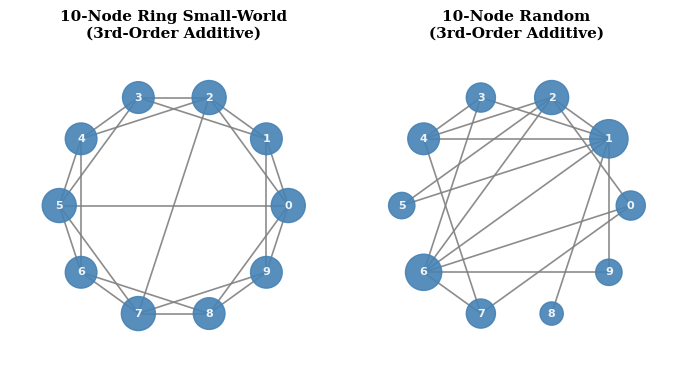

In [53]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Importamos los parámetros de tus scripts (asegúrate de que las rutas sean correctas)
from Scripts.parameters_10nodes import M_ring, M_rand

# --- Configuración de estilo para publicación (2-column paper) ---
import matplotlib as mpl
mpl.rcParams.update({
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'font.family':      'serif',
    'text.usetex':      False, # Cambiar a True si tienes LaTeX instalado
})

def plot_topology_comparison(M_left, M_right, title_left, title_right, savepath=None):
    """
    Genera una figura de 1 fila x 2 columnas con las topologías de red.
    Ancho: 7 pulgadas (ancho completo de página de 2 columnas).
    """
    FIG_W = 7.0
    FIG_H = 3.8
    
    fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
    
    matrices = [M_left, M_right]
    titles = [title_left, title_right]
    
    for i, ax in enumerate(axes):
        G = nx.from_numpy_array(matrices[i])
        pos = nx.circular_layout(G)
        
        # Cálculo de tamaños basado en grado para jerarquía visual
        degrees = dict(G.degree())
        node_sizes = [200 + 80 * degrees[n] for n in G.nodes()]
        
        # Dibujo de la red
        nx.draw(G, pos, ax=ax, 
                with_labels=True, 
                node_color='steelblue',
                node_size=node_sizes, 
                font_color='white', 
                font_weight='bold',
                font_size=8,
                edge_color='gray', 
                width=1.2,
                alpha=0.9)
        
        ax.set_title(titles[i], fontweight='bold', pad=10)
        
        # Ajustar límites para que no se corten los nodos
        ax.margins(0.15)

    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Figura guardada en: {savepath}")
    
    plt.show()

# --- Ejecución ---
# Definimos los títulos siguiendo tu nomenclatura
title_ring = "10-Node Ring Small-World\n(3rd-Order Additive)"
title_rand = "10-Node Random\n(3rd-Order Additive)"

plot_topology_comparison(
    M_left=M_ring, 
    M_right=M_rand, 
    title_left=title_ring, 
    title_right=title_rand,
    savepath="../results/topology_comparison.pdf"
)